In [1]:
import numpy as np
import matplotlib.pyplot as plt

from flab.empirics import rcsetup
rcsetup()
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

CLAUDE IGNORE

We are going to generate code to make a plot using matplotlib. It should have 4 panels, 2 columns and two rows. The first row panels should each be square, showing a flow map, while the second row panels will be shorter than they are wide, showing a slice of the loss surface. I'll give details now.

The first panel should show the optimization flow lines for the scalar problem L(p,q)=1/2(1-pq)^2. We are showing the p,q plane and trajectories on it. The lims should be [-0.2, 2] for both p and q. The p=0 and q=0 lines should be bold. The background will be colored to show the loss, but it should be faint so that the flow lines on top are clear to see. The flow lines are parametric curves of the form p^2 - q^2 = const. Draw them in solid black, with thin lines. Then, at regular intervals on the grid, draw flow arrows whose length corresponds to the gradient at that location, ie (m-pq)[q, p]. Draw a dashed red line on the p=q line.

The second panel should show the flow lines for the same problem under the muon optimizer. Everything will look the same, except the flow lines are parameteric curves of the form |p|-|q| = const, and the arrows point in the [\pm 1, \pm 1] direction accordingly, and their length is constant. Draw a dashed red line on the p=q line.

In the third panel, below the first, plot the loss as a function of p (p between [-1.5, 1.5]) along the line p=q. Simulate gradient descent starting from p=1e-2, and at each iterate draw a dot on the loss surface, with the dot changing color according to the cm.rainbow colormap as time goes forward. It should converge to the right side minimum. Choose the learning rate so that there are around 20 iterates before we are effectively converged.

In the fourth panel, below the second, plot the "effective loss" min(|p-1|,|p+1|) between [-1.5,1.5]. The muon flow starting from p=1e-2 will just take equal-sized steps (say, step size = 0.14) towards the right minimum, and then oscillate back and forth around the minimum. Plot the dots in the same way.

Please provide the code that makes this figure.

CLAUDE IGNORE

Consider the plotting code in section "old code". It currently makes arrowheads on a uniform grid, and then plots flow lines too. What I actually want to do is have a separate function which plots the contours and arrows in the following way:
* given the contour levels, first plot the faint dashed contour lines, as is already being done.
* Let g be a gap distance. For each contour line, we'll iterate over the (discretized) curve, starting at distance g from the curve 1/x and flowing away from that curve. We will alternate between the curve being "on" (where we draw an arrow) and the curve is "off" (only dashed line underneath). The "off" distance (along the contour curve) will always be g. The "on" distance will be f(np.hypot(Ug, Vg)) evaluated at the start point, where f(.) is a function of my choice (let's start with identity). The arrow will simply be an ax.plot along the contour such that the hypotenuse distance between its start and end points the on distance. The idea is to get curved arrows that follow the contours.
* draw the arrowhead at the start point, in the direction (Ug, Vg). Keep all arrowheads the same size, only arrow length should indicate magnitude.
* Be sure to draw the arrows on the other side of the 1/x curve too.

Do not change the code in the old code section. Just add new code to the cell below.

CLAUDE TODO

in the arrow plotting code, hard code the removal of the few arrows that intersect the "minimizer" text, which is at 
ax.text(1.7, 0.5, r"minimizer", fontsize=9, color="blue", alpha=0.6,
        rotation=-17, ha="center", va="center", zorder=20)
There are two such arrows in the gradient flow plot and three in the muon plot.


/tmp/ipykernel_1211186/173437287.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


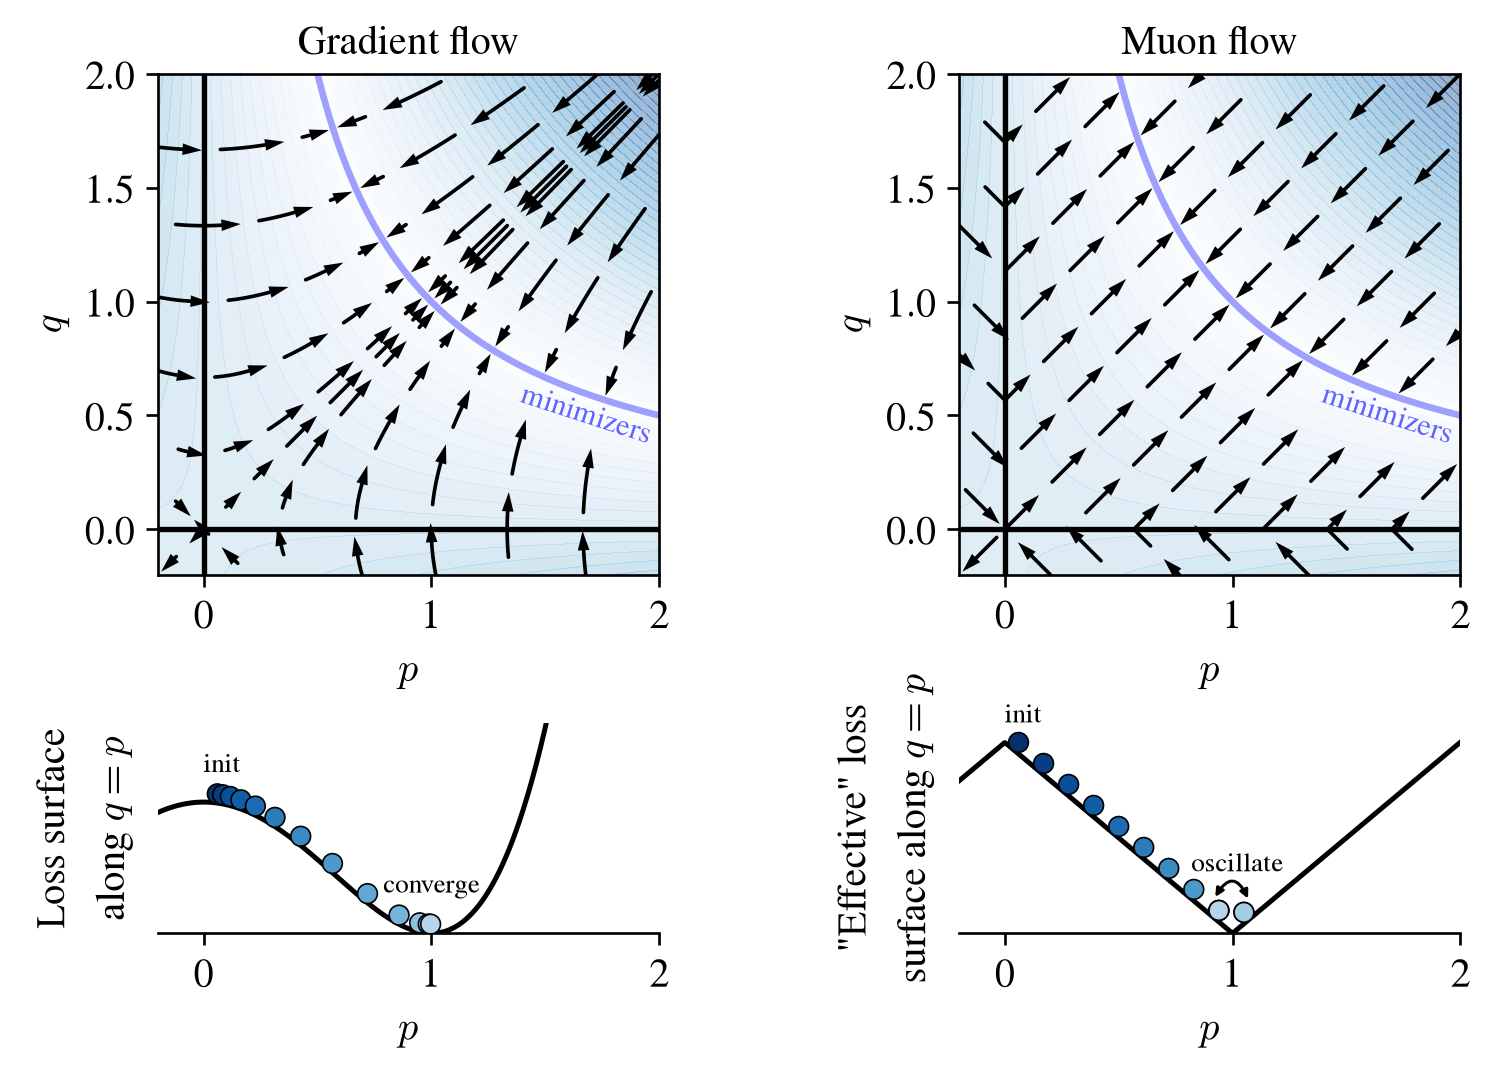

In [2]:
import contourpy
import matplotlib.patches as mpatches
from matplotlib import cm


# ---------------------------------------------------------------- helpers
def _contour_polylines(P, Q, field, levels):
    """Contour polylines of `field` at `levels`, computed without drawing.

    Uses contourpy (matplotlib's own contour backend) directly, so nothing is
    ever added to an axes -- this replaces the old `ax.contour(..., linewidths=0)`
    hack whose only purpose was to harvest the contour paths."""
    cg = contourpy.contour_generator(
        P, Q, field, line_type=contourpy.LineType.Separate)
    polys = []
    for lev in levels:
        for seg in cg.lines(float(lev)):
            seg = np.asarray(seg)
            if len(seg) > 1:
                polys.append(seg)
    return polys


def _arclen(seg):
    d = np.sqrt((np.diff(seg, axis=0) ** 2).sum(1))
    return np.concatenate([[0.0], np.cumsum(d)])


def _interp(seg, s, t):
    """Point on polyline `seg` (with cumulative arc length `s`) at arc length `t`."""
    t = np.clip(t, s[0], s[-1])
    i = max(1, min(int(np.searchsorted(s, t)), len(seg) - 1))
    denom = s[i] - s[i - 1]
    w = 0.0 if denom < 1e-15 else (t - s[i - 1]) / denom
    return seg[i - 1] + w * (seg[i] - seg[i - 1])


def _draw_head(ax, x, y, u, v, size, **kw):
    """Constant-size arrowhead at (x, y) pointing along (u, v)."""
    m = np.hypot(u, v)
    if m < 1e-12:
        return
    dx, dy = u / m * size, v / m * size
    ax.add_patch(mpatches.FancyArrow(
        x, y, dx, dy, head_length=size, head_width=0.6 * size,
        length_includes_head=True, overhang=0.0, **kw))


def flow_arrows(ax, P, Q, field, levels, Ufun, Vfun,
                valley=lambda p, q: p * q - 1.0,
                f=lambda m: m, g=0.16, head_len=0.065,
                skip=None, arrow_kw=None):
    """Draw curved arrows that follow the contours of `field` (the contour lines
    themselves are never drawn).

    For every contour we locate where it crosses the valley (`valley` == 0,
    here pq = 1), start a gap `g` away from it and march outward, alternating
    OFF (arc length g, gap only) and ON (an arrow whose body follows the contour
    until its chord length reaches f(|flow|) evaluated at the arrow's start
    point). The arrowhead sits at that valley-side start point, pointing along
    the flow (Ufun, Vfun), and is kept a constant size so only arrow *length*
    encodes magnitude. Arrows are drawn on both sides of the valley. `f` is a
    free choice (identity is the simplest); here the callers pass a saturating
    `f` so far-field arrows stay readable."""
    arrow_kw = dict(color="black", lw=1.1, solid_capstyle="round",
                    zorder=3) | (arrow_kw or {})

    for seg in _contour_polylines(P, Q, field, levels):
        if len(seg) < 2:
            continue
        s = _arclen(seg)
        L = s[-1]
        if L < g:
            continue

        # ---- anchors: (arc-pos of valley crossing, march-direction) ----
        val = valley(seg[:, 0], seg[:, 1])
        crossings = np.where(np.diff(np.signbit(val)))[0]
        anchors = []
        if len(crossings):
            for i in crossings:
                denom = val[i + 1] - val[i]
                w = 0.0 if abs(denom) < 1e-15 else -val[i] / denom
                s_cross = s[i] + w * (s[i + 1] - s[i])
                anchors += [(s_cross, +1), (s_cross, -1)]
        else:
            # contour never reaches the valley inside the box: start from the
            # end nearest the valley and march inward
            anchors.append((0.0, +1) if abs(val[0]) <= abs(val[-1]) else (L, -1))

        # ---- march along the contour placing arrows ----
        for s0, d in anchors:
            pos = s0 + d * g / 1.6                              # first OFF gap
            while 0.0 <= pos <= L:
                p0 = _interp(seg, s, pos)
                u, v = Ufun(p0[0], p0[1]), Vfun(p0[0], p0[1])
                on = f(np.hypot(u, v))                    # ON (chord) length
                if on < 1e-4:
                    break
                # walk outward until the chord from p0 reaches length `on`
                s2 = pos
                ds = d * max(L / 600.0, 1e-3)
                while 0.0 <= s2 <= L:
                    if np.hypot(*(_interp(seg, s, s2) - p0)) >= on:
                        break
                    s2 += ds
                s2 = float(np.clip(s2, 0.0, L))
                if abs(s2 - pos) < 1e-9:
                    break
                body = np.array([_interp(seg, s, si)
                                 for si in np.linspace(pos, s2, 16)])
                # hard-coded removal: drop arrows whose body/head would overlap
                # the "minimizer" text box (still advance pos so the dash/arrow
                # spacing along the rest of the contour is preserved)
                if skip is not None:
                    tip = p0 + np.array([u, v]) / np.hypot(u, v) * head_len
                    if np.any(skip(np.append(body[:, 0], tip[0]),
                                   np.append(body[:, 1], tip[1]))):
                        pos = s2 + d * g
                        continue
                ax.plot(body[:, 0], body[:, 1], **arrow_kw)
                _draw_head(ax, p0[0], p0[1], u, v, head_len,
                           fc=arrow_kw["color"], ec="none",
                           zorder=arrow_kw["zorder"])
                pos = s2 + d * g                          # next OFF gap


# ---------------------------------------------------------------- figure
xlim = (-0.2, 2.0)
ylim = (-0.2, 2.0)
p_grid = np.linspace(*xlim, 400)
q_grid = np.linspace(*ylim, 400)
P, Q = np.meshgrid(p_grid, q_grid)
L_full = 0.5 * (1.0 - P * Q) ** 2


# rotated box enclosing the "minimizer" text (center (1.7, 0.5), rotation -17 deg);
# arrows whose body/head land inside are dropped so they don't cross the label.
def in_text_box(x, y, cx=1.7, cy=0.5, ang=-17.0, half_w=0.42, half_h=0.085):
    th = np.deg2rad(ang)
    ct, st = np.cos(th), np.sin(th)
    dx, dy = np.asarray(x) - cx, np.asarray(y) - cy
    xp = ct * dx + st * dy        # along the text baseline
    yp = -st * dx + ct * dy       # across it
    return (np.abs(xp) <= half_w) & (np.abs(yp) <= half_h)


head_len=0.085
gap = 0.166
a = 0.2
b = 9.5
c= 0.5
# f_gd = lambda m: a/b * np.tanh(b * m)
f_gd = lambda m: a / (1 + np.exp(-b * (m - c)))
f_m = lambda m: 0.09 * m

def style_flow_panel(ax, title):
    ax.axhline(0, color="black", linewidth=1.6, zorder=4)
    ax.axvline(0, color="black", linewidth=1.6, zorder=4)
    pp = np.linspace(0.002, 2.0, 100)
    ax.plot(pp, 1 / pp, "b-", linewidth=2.0, zorder=-10, alpha=0.6)
    ax.text(1.68, 0.5, r"minimizers", fontsize=9, color="blue", alpha=0.6,
            rotation=-18, ha="center", va="center", zorder=20)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$p$")
    ax.set_ylabel(r"$q$")
    ax.set_title(title)


fig, axes = plt.subplots(
    2, 2, figsize=(7, 5),
    gridspec_kw={"height_ratios": [3, 1], "wspace": 0.6},
)

# ---- Panel 1: gradient flow (contours p^2 - q^2 = const) ----
U_gd = lambda p, q: (1 - p * q) * q
V_gd = lambda p, q: (1 - p * q) * p
# gd_levels = np.linspace(-3.5, 3.5, 16)            # even count -> skips 0 (the p=q line)
gd_levels = np.concatenate([-np.linspace(-2, 0, 7)[:-1]**2, np.linspace(0, 2, 7)**2])

ax = axes[0, 0]
# ax.contourf(P, Q, L_full, levels=20, cmap="Blues", alpha=0.30, zorder=0)
ax.contourf(P, Q, np.sqrt(L_full), levels=40, cmap="Blues", alpha=0.40, zorder=0)
flow_arrows(ax, P, Q, P ** 2 - Q ** 2, gd_levels, U_gd, V_gd,
            f=f_gd, g=gap, head_len=head_len, skip=in_text_box)
style_flow_panel(ax, "Gradient flow")

# ---- Panel 2: muon flow (contours |p| - |q| = const) ----
U_m = lambda p, q: np.sign((1 - p * q) * q)
V_m = lambda p, q: np.sign((1 - p * q) * p)
m_levels = np.linspace(-1.7, 1.7, 13)            # even count -> skips 0 (the p=q line)

ax = axes[0, 1]
ax.contourf(P, Q, np.sqrt(L_full), levels=40, cmap="Blues", alpha=0.40, zorder=0)
flow_arrows(ax, P, Q, np.abs(P) - np.abs(Q), m_levels, U_m, V_m,
            f=f_m, g=gap, head_len=head_len, skip=in_text_box)
style_flow_panel(ax, "Muon flow")

# ---- Panel 3: GD along p = q ----
p_line = np.linspace(-0.2, 2.0, 600)
n_iter = 12

ax = axes[1, 0]
L_diag = 0.5 * (1 - p_line ** 2) ** 2
ax.plot(p_line, L_diag, "k-", linewidth=1.5)
eta_gd = 0.4
p = 6e-2
traj_gd = [p]
for _ in range(n_iter):
    p = p + eta_gd * (1 - p ** 2) * p
    traj_gd.append(p)
traj_gd = np.array(traj_gd)
losses_gd = 0.5 * (1 - traj_gd ** 2) ** 2
ax.scatter(traj_gd, losses_gd + 0.035,
           c=cm.Blues_r(np.linspace(0, .7, len(traj_gd))),
           s=35, zorder=5, edgecolors="black", linewidths=0.5)
ax.text(0.08, 0.64, "init", fontsize=8, ha="center", va="center")
ax.text(1.0, 0.13, "converge", fontsize=8, ha="center", va="bottom")
for sp in ("top", "left", "right"):
    ax.spines[sp].set_visible(False)
ax.set_yticks([])
ax.set_xlim(-0.2, 2.0)
ax.set_ylim(0.0, 0.8)
ax.set_xlabel(r"$p$")
ax.set_ylabel("Loss surface\nalong $q=p$")

# ---- Panel 4: muon along p = q ----
ax = axes[1, 1]
L_eff = np.minimum(np.abs(p_line - 1), np.abs(p_line + 1))
ax.plot(p_line, L_eff, "k-", linewidth=1.5)
step = 0.11
p = 6e-2
traj_m = [p]
for _ in range(n_iter):
    p = p + step * np.sign((1 - p ** 2) * p)
    traj_m.append(p)
traj_m = np.array(traj_m)
losses_m = np.minimum(np.abs(traj_m - 1), np.abs(traj_m + 1))
ax.scatter(traj_m, losses_m + 0.06,
           c=cm.Blues_r(np.linspace(0, .7, len(traj_m))),
           s=35, zorder=5, edgecolors="black", linewidths=0.5)
p_a, p_b = traj_m[-1] - 0.03, traj_m[-2] + 0.03
arrow = mpatches.FancyArrowPatch(
    (p_a, losses_m[-1] + 0.1), (p_b, losses_m[-2] + 0.1),
    arrowstyle="<|-|>", connectionstyle="arc3,rad=-1.1",
    color="black", lw=0.9, mutation_scale=5)
ax.add_patch(arrow)
ax.text(0.08, 1.14, "init", fontsize=8, ha="center", va="center")
ax.text(1.02, 0.29, "oscillate", fontsize=8, ha="center", va="bottom")
for sp in ("top", "left", "right"):
    ax.spines[sp].set_visible(False)
ax.set_yticks([])
ax.set_xlim(-0.2, 2.0)
ax.set_ylim(0.0, 1.1)
ax.set_xlabel(r"$p$")
ax.set_ylabel('"Effective" loss\nsurface along $q=p$')

plt.tight_layout()
plt.savefig('plots/fig2.pdf', bbox_inches='tight')
plt.show()